In [1]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/projects/image-to-black-white/src")

In [2]:
import os
from PIL import Image


# Sciezki folderow
folder_zrodlowy = "../data"
folder_docelowy = "../out"


# Tworzenie folderu docelowego, jesli nie istnieje
if not os.path.exists(folder_docelowy):
    os.makedirs(folder_docelowy)


# Lista rozszerzen plikow do konwersji
rozszerzenia = [".jpg", ".jpeg", ".png"]


# Petla po plikach w folderze zrodlowym
for nazwa_pliku in os.listdir(folder_zrodlowy):
    # Sprawdzanie, czy plik ma odpowiednie rozszerzenie
    
    sciezka_zrodlowa = ""
    
    if any(nazwa_pliku.lower().endswith(ext) for ext in rozszerzenia):
        # Tworzenie pelnej sciezki do pliku zrodlowego
        sciezka_zrodlowa = os.path.join(folder_zrodlowy, nazwa_pliku)


    try:
        # Otwieranie obrazu
        obraz = Image.open(sciezka_zrodlowa)


        # Tworzenie nazwy pliku docelowego
        nazwa_pliku_docelowego = os.path.splitext(nazwa_pliku)[0] + ".jpg"
        sciezka_docelowa = os.path.join(
        folder_docelowy, nazwa_pliku_docelowego
        )


        # Konwersja i zapisywanie obrazu
        obraz = obraz.convert("RGB")  # Konwersja do trybu RGB
        obraz.save(sciezka_docelowa, "JPEG")


        print(f"Skonwertowano i zapisano: {nazwa_pliku} -> {nazwa_pliku_docelowego}")
    except Exception as e:
        print(f"Blad podczas konwersji {nazwa_pliku}: {e}")


print("Konwersja zakonczona.")

Blad podczas konwersji .ipynb_checkpoints: 'str' object has no attribute 'read'
Skonwertowano i zapisano: image1.jpeg -> image1.jpg
Skonwertowano i zapisano: image2.jpg -> image2.jpg
Skonwertowano i zapisano: image3.jpg -> image3.jpg
Skonwertowano i zapisano: image4.png -> image4.jpg
Skonwertowano i zapisano: image5.jpg -> image5.jpg
Konwersja zakonczona.


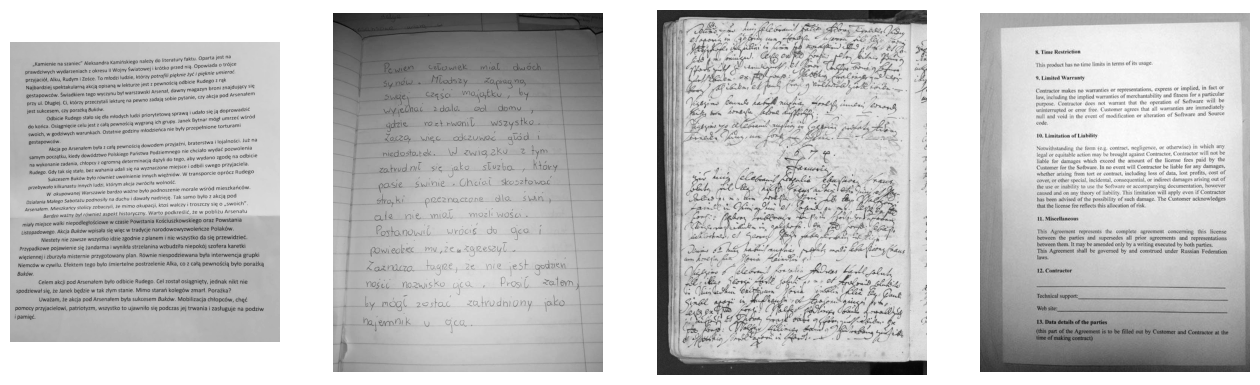

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

nazwy_plikow = [
    # "../out/image1.jpg",
    "../out/image2.jpg",
    "../out/image3.jpg",
    "../out/image4.jpg",
    "../out/image5.jpg"
]

rows = 1
columns = 4

fig = plt.figure(figsize=(16, 8))

images = []

for i, nazwa_pliku in enumerate(nazwy_plikow):
    if not os.path.exists(nazwa_pliku):
        print("plik", nazwa_pliku, "nie istnieje")
        continue
        
    img = cv2.imread(nazwa_pliku)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # img = cv2.filter2D(img, -1, kernel1)
    
    images.append(img)
    
    fig.add_subplot(rows, columns, i + 1)
    plt.axis('off')
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    
plt.show()
    

# plt.imshow(img, cmap=plt.get_cmap('gray'))

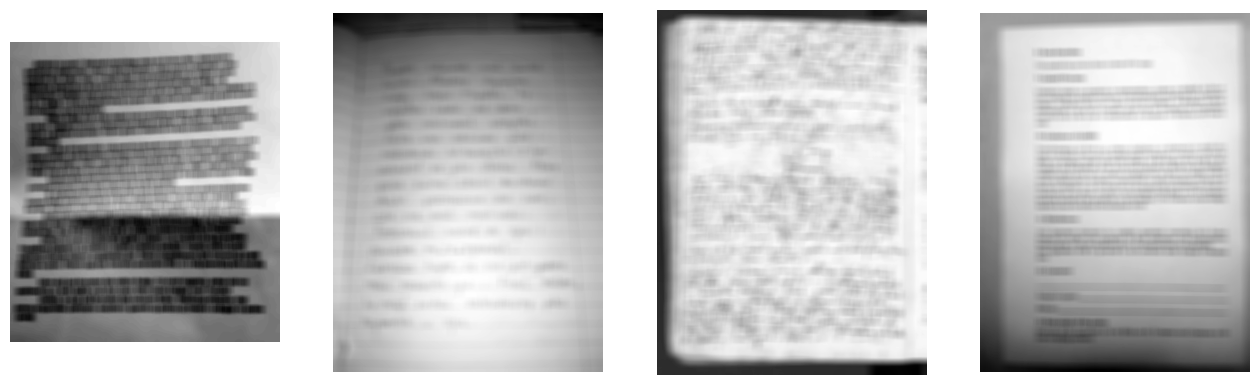

In [4]:
import matplotlib.gridspec as gridspec

# image = images[2].copy()

rows = 1
columns = 4

fig = plt.figure(figsize=(16, 8))

filtered_images = []

def changeImage(img, rows_cnt, columns_cnt):
    img_height, img_width = img.shape
    
    # print(img_width, ",", img_height)
    
    sec_w = img_width // columns_cnt
    sec_h = img_height // rows_cnt
    matrix = np.full((sec_w, sec_h), 1 / (sec_w*sec_h))
    
    img = cv2.filter2D(img, -1, matrix)
    # print(matrix)
    
    return img

for i, img in enumerate(images):
    new_img = changeImage(img, 32, 32)
    filtered_images.append(new_img)
    
    fig.add_subplot(rows, columns, i + 1)
    plt.axis('off')
    plt.imshow(new_img, cmap=plt.get_cmap('gray'))

plt.show()

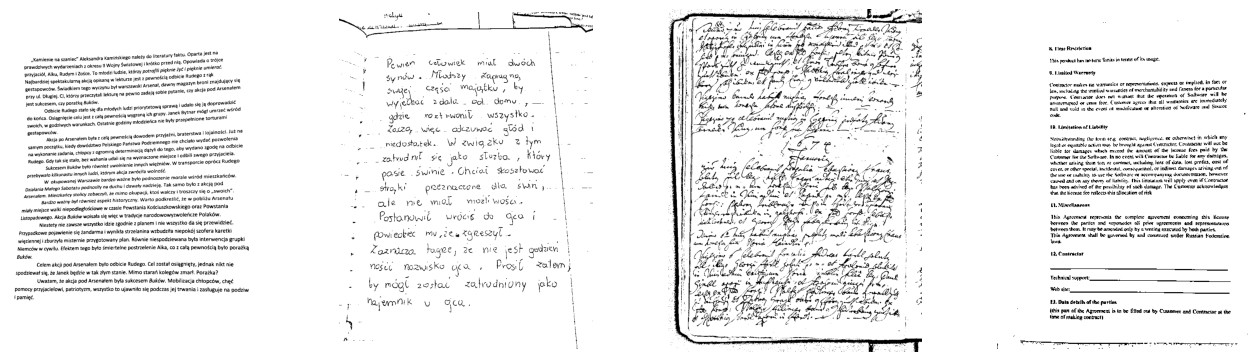

In [5]:
# fig = plt.figure(figsize=(8 * image_width / higher_value, 8 * image_height / higher_value))
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.3, hspace=0.3)

# print("image sizes")
# print(image_width, "-", image_height)
# print("_________________")

def editImage(image, filtered_image):
    image_height, image_width = image.shape
    
    for r in range(image_height):
        for c in range(image_width):
            
            image_part_avg = filtered_image[r, c]
            prog = image_part_avg * 0.825

            if image[r, c] <= prog:
                image[r, c] = 0
            else:
                image[r, c] = 255
                
    return image
    
new_images = []
    
for i, (img, flt_img) in enumerate(zip(images, filtered_images)):
    img_cp = img.copy()
    img_cp = editImage(img_cp, flt_img)
    new_images.append(img_cp)
    
    fig.add_subplot(gs[0, i])
    plt.axis('off')
    plt.imshow(img_cp, cmap=plt.get_cmap('gray'))
    
plt.show()

In [6]:
for i, x in enumerate(new_images):
    print(f"saving {i}th image")
    cv2.imwrite(f"../out3/image{i}.jpg", x)

saving 0th image
saving 1th image
saving 2th image
saving 3th image
